In [164]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

In [165]:
# ---- Classical linear code definition ----
# Parity-check matrix H (shape (n-k) x n). Default: [3,1,3] repetition code.
H = np.array([[1, 1, 0],
              [0, 1, 1]]) % 2
n   = H.shape[1]          # number of physical bits   (3)
m   = H.shape[0]          # number of checks = n - k  (2)
k   = n - m               # logical bits              (1)
dim = 2 ** n              # state-space dimension      (8)

I2 = np.eye(2)
X  = np.array([[0., 1.], [1., 0.]])          # Pauli X = classical bit flip

def x_string(bits):
    """X^bits = tensor product of X on every position where bits[j]==1."""
    M = np.array([[1.0]])
    for b in bits:
        M = np.kron(M, X if b else I2)
    return M

def syndrome(e):
    """Syndrome H e (mod 2) of an n-bit error pattern e, returned as a tuple."""
    return tuple((H @ np.array(e)) % 2)

def build_decoder(H, n):
    """Minimum-weight lookup decoder: syndrome -> correction bitstring."""
    m = H.shape[0]
    table = {}
    for w in range(n + 1):                       # errors in order of increasing weight
        for combo in itertools.combinations(range(n), w):
            e = np.zeros(n, dtype=int)
            for i in combo:
                e[i] = 1
            s = tuple((H @ e) % 2)
            if s not in table:                   # keep first (lowest-weight) representative
                table[s] = e
        if len(table) == 2 ** m:
            break
    return table

decoder = build_decoder(H, n)

def R_op(s):
    """Recovery operator R_s = X^{corr(s)} for syndrome s."""
    return x_string(decoder[tuple(np.array(s) % 2)])

{s: list(c) for s, c in decoder.items()}     # show the decoding table

{(np.int64(0), np.int64(0)): [np.int64(0), np.int64(0), np.int64(0)],
 (np.int64(1), np.int64(0)): [np.int64(1), np.int64(0), np.int64(0)],
 (np.int64(1), np.int64(1)): [np.int64(0), np.int64(1), np.int64(0)],
 (np.int64(0), np.int64(1)): [np.int64(0), np.int64(0), np.int64(1)]}

In [166]:
# ---- Error model ----
# Independent bit-flip with parameter q, applied both to the n-bit error pattern e~
# and (directly) to the (n-k)-bit syndrome label e_i.
def p_error(e, q):
    """p(e~) = prod_j q^{e_j} (1-q)^{1-e_j} for an n-bit error pattern e."""
    w = int(np.sum(e))
    return q ** w * (1 - q) ** (n - w)

def syndrome_dist(q):
    """Syndrome-label distribution p(e_i): each of the (n-k) syndrome bits is an
    independent bit-flip(q).  Same iid form as p_error, applied to the length-(n-k)
    syndrome bitstring (NOT induced from the error distribution)."""
    return {e: q ** int(sum(e)) * (1 - q) ** (m - int(sum(e))) for e in S}

S = list(itertools.product([0, 1], repeat=m))   # all 2^(n-k) syndrome labels

In [167]:
# ---- Channel construction via superoperators ----
# Column-major vectorization: the map  rho -> K rho K^dagger  becomes  (K* (x) K) vec(rho).
def to_super(K):   return np.kron(K.conj(), K)
def vec(rho):      return rho.reshape(-1, order='F')
def unvec(v):      return v.reshape(dim, dim, order='F')
ISUP = np.eye(dim * dim, dtype=complex)          # identity superoperator (channel at t=0)

def build_SQ(q):
    """SQ[ei][eim1] = superoperator of  Q(e_i, e_{i-1})[rho]
       = sum_{e~} p(e~) R_s X^{e~} rho X^{e~} R_s,  with s = (H e~ + e_i + e_{i-1}) mod 2.
    Note: Q itself shifts the state's syndrome by exactly e_i (+) e_{i-1} (the error e~ cancels,
    because H corr(s) = s); the syndrome is reset to the input only by the trailing R(e_t) below."""
    SQ = {ei: {} for ei in S}
    for ei in S:
        for eim1 in S:
            acc = np.zeros((dim * dim, dim * dim), dtype=complex)
            for et in itertools.product([0, 1], repeat=n):
                s = tuple((np.array(syndrome(et)) + np.array(ei) + np.array(eim1)) % 2)
                U = R_op(s) @ x_string(et)       # recovery composed with the error
                acc += p_error(et, q) * to_super(U)
            SQ[ei][eim1] = acc
    return SQ

def build_all_channels(T, q):
    """Cache the superoperator of the dynamical map  channel(t)  for t = 0..T.

    channel(t) = sum_{e1..et} p(e1)..p(et) R(et) Q(et,e_{t-1})..Q(e2,e1) R(e1)
                 (channel(1) = R(e1) R(e1) = I).

    Each snapshot ENDS with the terminal decode R(e_t): the Q's shift the running syndrome to e_t,
    and the trailing R(e_t) corrects it straight back, so channel(t) maps every syndrome sector to
    itself (the syndrome is reset to the input each step, not left tracking e_t). The trailing R(e_t)
    is applied ONLY when forming the snapshot; the recursion state C is kept UN-decoded so the next
    step's Q(e_{t+1},e_t) propagates the physical (undecoded) trajectory.
    Built by a transfer-matrix recursion over the syndrome path e1 -> ... -> et."""
    psyn = syndrome_dist(q)
    SR   = {e: to_super(R_op(e)) for e in S}     # recovery superoperators (initial R(e1) and trailing R(et))
    SQ   = build_SQ(q)
    chans = {0: ISUP.copy()}                      # channel(0) = identity
    C = {e: psyn[e] * SR[e] for e in S}           # un-decoded state after the initial R(e1), weighted by p(e1)
    chans[1] = sum(SR[e] @ C[e] for e in S)       # t=1: trailing R(e1) undoes the lone R(e1)  ->  identity
    for t in range(2, T + 1):
        C = {ei: psyn[ei] * sum(SQ[ei][eim1] @ C[eim1] for eim1 in S) for ei in S}
        chans[t] = sum(SR[ei] @ C[ei] for ei in S)   # partial product, THEN trailing decode R(e_t)
    return chans

def make_channel(chans):
    """Wrap the cached superoperators as a callable channel(t, rho)."""
    return lambda t, rho: unvec(chans[t] @ vec(rho))

In [168]:
# ---- Non-Markovianity (BLP) measure ----
# trace_norm(diag(p1-p2)) = ||p1-p2||_1 = 2 * total-variation distance for the classical case.
def trace_norm(A):
    return np.sum(np.abs(np.linalg.eigvalsh(A)))

def non_markovian_measure(channel, T, rho1, rho2):
    rho = rho1 - rho2
    measure = 0
    for t in range(1, T):
        measure += max(0, 0.5 * (trace_norm(channel(t, rho)) - trace_norm(channel(t - 1, rho))))

    return measure

In [169]:
# ---- Sweep rho1, rho2 over all physical basis states; find the maximum ----
def basis_state(i):
    """Pure computational-basis state |i><i| as a diagonal density matrix."""
    rho = np.zeros((dim, dim), dtype=complex)
    rho[i, i] = 1.0
    return rho

def max_measure(T, q):
    """Maximum non-Markovian measure over all pairs of basis states, plus the optimal pair."""
    channel = make_channel(build_all_channels(T, q))
    best_val, best_pair = -1.0, None
    for i in range(dim):
        for j in range(i + 1, dim):
            v = non_markovian_measure(channel, T, basis_state(i), basis_state(j))
            if v > best_val:
                best_val, best_pair = v, (i, j)
    return best_val, best_pair

T = 12
q = 0.1
val, (i, j) = max_measure(T, q)
print(f"code: n={n}, k={k}   T={T}   q={q}")
print(f"max non-Markovian measure = {val:.6f}")
print(f"optimal state pair: |{i:0{n}b}>  vs  |{j:0{n}b}>")

code: n=3, k=1   T=12   q=0.1
max non-Markovian measure = 0.000000
optimal state pair: |100>  vs  |101>


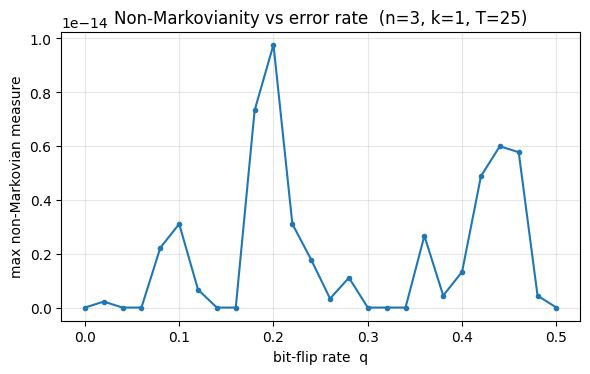

In [170]:
# ---- Sweep the bit-flip rate q and plot the maximised measure ----
T  = 25
qs = np.linspace(0.0, 0.5, 26)
vals = [max_measure(T, q)[0] for q in qs]

plt.figure(figsize=(6, 4))
plt.plot(qs, vals, marker='o', ms=3)
plt.xlabel('bit-flip rate  q')

plt.ylabel('max non-Markovian measure')
plt.title(f'Non-Markovianity vs error rate  (n={n}, k={k}, T={T})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

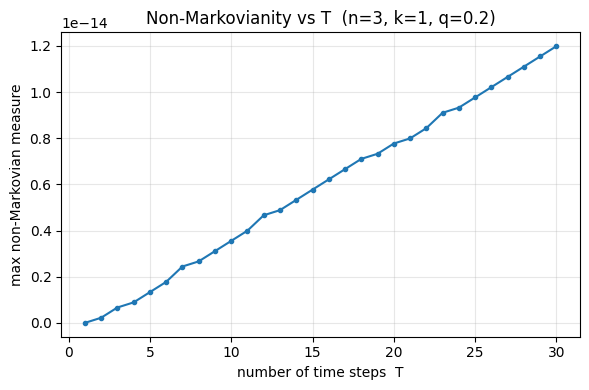

In [171]:
# ---- Measure vs number of time steps T (at fixed q) ----
q    = 0.2
Tmax = 30
channel = make_channel(build_all_channels(Tmax, q))   # build once, reuse for every T

def max_measure_fixed(channel, T):
    """Max non-Markovian measure over basis-state pairs, reusing a prebuilt channel."""
    best = -1.0
    for i in range(dim):
        for j in range(i + 1, dim):
            best = max(best, non_markovian_measure(channel, T, basis_state(i), basis_state(j)))
    return best

Ts   = list(range(1, Tmax + 1))
vals = [max_measure_fixed(channel, T) for T in Ts]

plt.figure(figsize=(6, 4))
plt.plot(Ts, vals, marker='o', ms=3)
plt.xlabel('number of time steps  T')
plt.ylabel('max non-Markovian measure')
plt.title(f'Non-Markovianity vs T  (n={n}, k={k}, q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[[ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j -0.5+0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j -0.5+0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j  0. +0.j]]
[np.complex128(0j), np.complex128(0.3484714496000001+0j), np.complex128(0.4242357248000001+0j), np.complex128(-0.4242357248000001+0j), np.complex128(-0.07576427520000004+0j), np.complex128(0.07576427520000004+0j), np.complex128(-0.3484714496000001+0j), np.complex128(0j)]
[[ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        

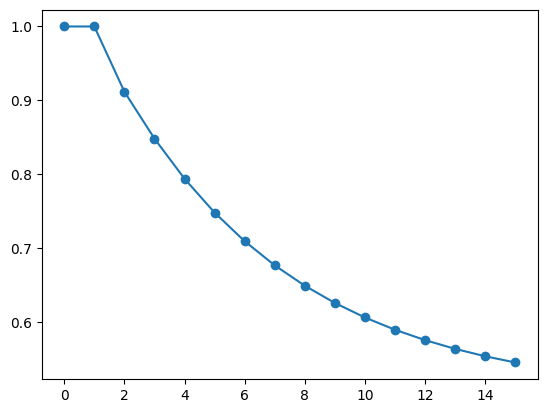

In [172]:
q = 0.1
Tmax = 15
channel = make_channel(build_all_channels(Tmax, q))

rho = (basis_state(1) + basis_state(2)) * 0.5 - (basis_state(3) + basis_state(6)) * 0.5

print(rho)
M = channel(3,rho)

print([M[m][m] for m in range(dim)])
print(channel(3,rho))

ts = list(range(0, Tmax + 1))
dist = [0.5 * trace_norm(channel(t,rho)) for t in ts ]

plt.plot(ts, dist, marker = 'o')
plt.show()

1.0


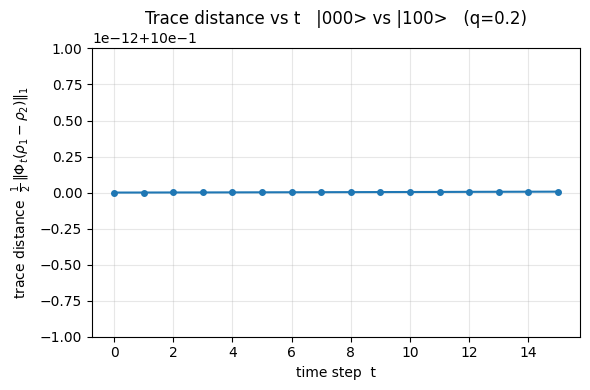

t= 0  D=1.000000
t= 1  D=1.000000
t= 2  D=1.000000
t= 3  D=1.000000
t= 4  D=1.000000
t= 5  D=1.000000
t= 6  D=1.000000
t= 7  D=1.000000
t= 8  D=1.000000
t= 9  D=1.000000
t=10  D=1.000000
t=11  D=1.000000
t=12  D=1.000000
t=13  D=1.000000
t=14  D=1.000000
t=15  D=1.000000


In [173]:
# ---- Raw trace distance vs t for the optimal state pair ----
# This is the un-thresholded quantity behind the BLP measure: D(t) = 1/2 ||Phi_t(rho1-rho2)||_1.
# Markovian (CP-divisible) dynamics => D(t) monotonically non-increasing.
# Any revival (upward step) is exactly what non_markovian_measure sums.
q    = 0.2
Tmax = 15
channel = make_channel(build_all_channels(Tmax, q))

#_, (i, j) = max_measure(Tmax, q)                 # optimal basis-state pair at this q
i = 0
j = 4
#delta = basis_state(i) - basis_state(j)
delta = (basis_state(1) + basis_state(2)) * 0.5 - (basis_state(7) + basis_state(3)) * 0.5
print(0.5 * trace_norm(delta))
ts   = list(range(0, Tmax + 1))
dist = [0.5 * trace_norm(channel(t, delta)) for t in ts]

plt.figure(figsize=(6, 4))
plt.plot(ts, dist, marker='o', ms=4)
plt.xlabel('time step  t')
plt.ylabel(r'trace distance  $\frac{1}{2}\,\|\Phi_t(\rho_1-\rho_2)\|_1$')
plt.title(f'Trace distance vs t   |{i:0{n}b}> vs |{j:0{n}b}>   (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for t, d in zip(ts, dist):
    print(f"t={t:2d}  D={d:.6f}")

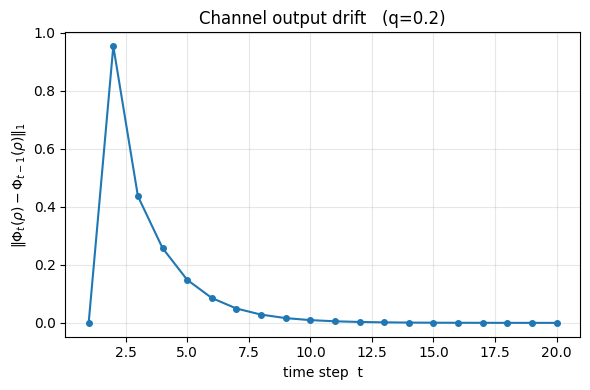

t= 1  ||dPhi(rho)||_1=0.000000
t= 2  ||dPhi(rho)||_1=0.954214
t= 3  ||dPhi(rho)||_1=0.436584
t= 4  ||dPhi(rho)||_1=0.257836
t= 5  ||dPhi(rho)||_1=0.148488
t= 6  ||dPhi(rho)||_1=0.085747
t= 7  ||dPhi(rho)||_1=0.049505
t= 8  ||dPhi(rho)||_1=0.028582
t= 9  ||dPhi(rho)||_1=0.016502
t=10  ||dPhi(rho)||_1=0.009527
t=11  ||dPhi(rho)||_1=0.005501
t=12  ||dPhi(rho)||_1=0.003176
t=13  ||dPhi(rho)||_1=0.001834
t=14  ||dPhi(rho)||_1=0.001059
t=15  ||dPhi(rho)||_1=0.000611
t=16  ||dPhi(rho)||_1=0.000353
t=17  ||dPhi(rho)||_1=0.000204
t=18  ||dPhi(rho)||_1=0.000118
t=19  ||dPhi(rho)||_1=0.000068
t=20  ||dPhi(rho)||_1=0.000039


In [174]:
# ---- Channel drift:  ||channel(t, rho) - channel(t-1, rho)||_1 ----
# Shows the dynamical map settling: this difference decays monotonically to 0 as the channel
# relaxes to its steady state. With the corrected (partial-product) family the trace distance
# is monotonically non-increasing, so there is no backflow and the BLP measure is 0.
q    = 0.2
Tmax = 20
channel = make_channel(build_all_channels(Tmax, q))

rho1 = basis_state(int('100', 2))
rho2 = basis_state(int('101', 2))                # a pure computational-basis input state
rho = rho1 - rho2

ts   = list(range(1, Tmax + 1))
diff = [trace_norm(channel(t, rho) - channel(t - 1, rho)) for t in ts]

plt.figure(figsize=(6, 4))
plt.plot(ts, diff, marker='o', ms=4)
plt.xlabel('time step  t')
plt.ylabel(r'$\|\Phi_t(\rho) - \Phi_{t-1}(\rho)\|_1$')
plt.title(f'Channel output drift   (q={q})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for t, d in zip(ts, diff):
    print(f"t={t:2d}  ||dPhi(rho)||_1={d:.6f}")

In [178]:
# ---- Model B (option i): one-step QEC channel that DECODES the input syndrome first ----
# One cycle on input rho:
#   e0 = syndrome(rho)            (the input's own syndrome sector)
#   apply error X^{e~} (iid bit-flip p); read the syndrome corrupted by a label flip e1 (iid p);
#   recover with the VARIANT-A rule  s = syndrome(e~) (+) e1 (+) e0,  bracketed by R(e1) and R(e0):
#       K = R(e1) R(s) X^{e~} R(e0)
# Decoding the input (R(e0)) is what makes channel(1) coincide with channel_one_step for EVERY
# input; vs the e0=0 version they agree only on codewords (where e0=0).  e0 is read per syndrome
# sector via the projectors P_sigma, so the map stays linear on any (diagonal) rho1 - rho2.

p = 0.1

def prob(bits, p):
    """iid bit-flip(p) probability of a 0/1 pattern of any length."""
    w = sum(bits)
    return p ** w * (1 - p) ** (len(bits) - w)

def to_bits(nn, width=n):
    """Integer -> width-bit list, MSB first (same convention as x_string / basis_state)."""
    return [(nn >> (width - 1 - i)) & 1 for i in range(width)]

def P_syndrome(sigma):
    """Projector onto the computational-basis states whose syndrome equals sigma."""
    P = np.zeros((dim, dim))
    for x in range(dim):
        if syndrome(to_bits(x, n)) == tuple(sigma):
            P[x, x] = 1.0
    return P

def channel_one_step(rho, p):
    """One variant-A QEC cycle that decodes the input syndrome first (e0 = syndrome(rho))."""
    out = np.zeros((dim, dim), dtype=complex)
    for e0 in S:                                            # input syndrome sector
        P = P_syndrome(e0)
        rho0 = P @ rho @ P
        if not np.any(rho0):
            continue
        Re0 = R_op(e0)
        for e1 in S:                                        # syndrome-label noise
            pe1 = prob(e1, p)
            for et in itertools.product([0, 1], repeat=n):  # physical error e~
                pet = prob(et, p)
                s = tuple((np.array(syndrome(et)) + np.array(e1) + np.array(e0)) % 2)
                K = R_op(e1) @ R_op(s) @ x_string(et) @ Re0     # Kraus: R(e1) R(s) X^{e~} R(e0)
                out += pe1 * pet * (K @ rho0 @ K.conj().T)
    return out

def build_all_channels_B(T, p):
    """Multi-step channel
         channel(t) = sum_{e1..et} prod_i p(e_i)  R(et) Q(et,e_{t-1}) .. Q(e1,e0) R(e0),
       with e0 = syndrome(input) and VARIANT-A Q (build_SQ): the label e_i is SHARED between
       adjacent factors Q(e_{i+1},e_i) and Q(e_i,e_{i-1}) via s = H e~ (+) e_i (+) e_{i-1}.
       Built per input sector e0=sigma by the same transfer-matrix recursion as build_all_channels,
       then reassembled with the sector projectors P_sigma."""
    SQ = build_SQ(p)                                        # variant-A Q superoperators (reused)
    SR = {e: to_super(R_op(e)) for e in S}
    Pp = {sig: to_super(P_syndrome(sig)) for sig in S}
    psyn = {e: prob(e, p) for e in S}
    chans = {0: ISUP.copy()}
    # C[sigma][e1] = p(e1) * Q(e1,sigma) R(sigma)   (partial product, not yet trailing-decoded)
    C = {sig: {e1: psyn[e1] * (SQ[e1][sig] @ SR[sig]) for e1 in S} for sig in S}
    snap = lambda C: sum((sum(SR[ei] @ C[sig][ei] for ei in S)) @ Pp[sig] for sig in S)
    chans[1] = snap(C)
    for t in range(2, T + 1):
        C = {sig: {ei: psyn[ei] * sum(SQ[ei][eim1] @ C[sig][eim1] for eim1 in S) for ei in S}
             for sig in S}
        chans[t] = snap(C)
    return chans

# verify channel(1) coincides with channel_one_step for every input
chans_B = build_all_channels_B(12, p)
_maxdiff = max(np.linalg.norm(unvec(chans_B[1] @ vec(basis_state(x))) - channel_one_step(basis_state(x), p))
               for x in range(dim))
print(f"max |channel(1) - channel_one_step| over basis states = {_maxdiff:.2e}")

max |channel(1) - channel_one_step| over basis states = 3.33e-16


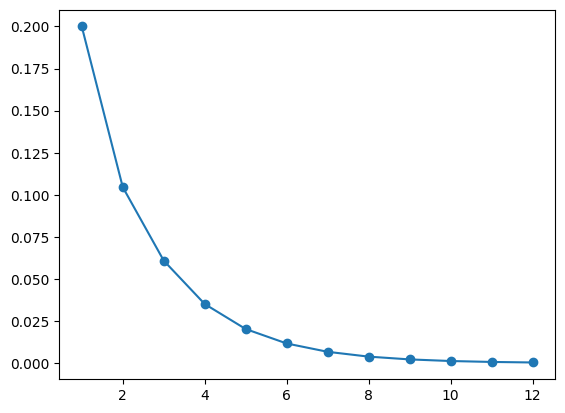

In [181]:
p1 = 0.1
p2 = 0.3
def input_state(p):
    return  (1-p) * basis_state(0) + p * basis_state(7)

rho1 = input_state(p1)
rho2 = input_state(p2)
Tmax = 12
ts = list(range(1, Tmax + 1))
M = channel(5,rho1-rho2)

dict = [0.5 * trace_norm(channel(t, rho1-rho2)) for t in ts]

plt.plot(ts,dict, marker = 'o')

In [182]:
# ---- Maximise the BLP non-Markovian measure over (p1, p2) ----
# input_state(p) = (1-p)|000><000| + p|111><111|  (codeword mixture, defined in the cell above).
# BLP = sum over t of the POSITIVE gradient steps of  D(t) = 0.5||Phi_t(rho1 - rho2)||_1.
# Also report the largest single positive step (a "revival") found over all (p1, p2).
q    = 0.1
Tmax = 15
channel = make_channel(build_all_channels(Tmax, q))

def blp_pair(channel, T, p1, p2):
    rho = input_state(p1) - input_state(p2)
    D = [0.5 * trace_norm(channel(t, rho)) for t in range(T + 1)]
    steps = [D[t] - D[t - 1] for t in range(1, T + 1)]
    return sum(s for s in steps if s > 0), max(steps)     # (BLP measure, largest single step)

grid = np.linspace(0, 1, 51)
best, best_pair, best_step = -1.0, None, -np.inf
for p1 in grid:
    for p2 in grid:
        if p1 == p2:
            continue
        blp, mx = blp_pair(channel, Tmax, p1, p2)
        if blp > best:
            best, best_pair = blp, (round(p1, 3), round(p2, 3))
        best_step = max(best_step, mx)

print(f"max BLP measure over (p1, p2)           = {best:.3e}   at {best_pair}")
print(f"largest positive gradient (any pair, t) = {best_step:.3e}")
print("  > 0  => a revival (backflow) exists;  <= 0  => D(t) decays monotonically for every pair")

# Note: rho1 - rho2 = (p1 - p2) (|111><111| - |000><000|) is collinear for every (p1, p2),
# so D(t) = |p1 - p2| * D_Delta(t): the curve SHAPE (and the sign of every gradient) does not
# depend on (p1, p2); BLP just scales with |p1 - p2|, maxed at the pure pair p1=1, p2=0.

max BLP measure over (p1, p2)           = 0.000e+00   at (np.float64(0.0), np.float64(0.02))
largest positive gradient (any pair, t) = 0.000e+00
  > 0  => a revival (backflow) exists;  <= 0  => D(t) decays monotonically for every pair


In [191]:
p1 = 0
Tmax = 5
rho = input_state(p1)
ts = list(range(1, Tmax + 1))

rho_final = channel(Tmax,rho)
p = rho_final[7][7]

p1 = 1
rho = input_state(p1)
rho_final = channel(Tmax,rho)
q = rho_final[0][0]

A_T = np.array([[1-p,q],[p,1-q]])

print(A_T)

[[0.85376709+0.j 0.14623291+0.j]
 [0.14623291+0.j 0.85376709+0.j]]


In [195]:
rho_test = input_state(0.1)
print([channel(Tmax,rho_test)[m][m] for m in list((0,7))])

print(A_T @ np.array([0.9,0.1]))

[np.complex128(0.7830136699589539+0j), np.complex128(0.2169863300410454+0j)]
[0.78301367+0.j 0.21698633+0.j]


In [206]:
def stochastic_matrix(t, channel):
    p = channel(t,input_state(0))[7][7]
    q = channel(t,input_state(1))[0][0]

    return np.array([[1-p,q],[p,1-q]])

T = 8
A_T = stochastic_matrix(T, channel)
A_t_1 = stochastic_matrix(T-1, channel)

M = A_T @ np.linalg.inv(A_t_1)
print(M)

print(M[0][0] + M[1][0] - 1.0)
print(M[0][1] + M[1][1] - 1.0)

[[0.92218105+0.j 0.07781895+0.j]
 [0.07781895+0.j 0.92218105+0.j]]
0j
(2.220446049250313e-16+0j)


In [208]:
# ---- Sweep T and check M = A_T @ inv(A_{T-1}) is a valid stochastic matrix at every step ----
# Valid (column-)stochastic matrix: all entries >= 0  AND  every COLUMN sums to 1.0.
# M is defined for t >= 2 (needs A_T and A_{T-1}).
Tmax = 20
q    = 0.2
channel = make_channel(build_all_channels(Tmax, q))   # build once, reuse for every T

tol = 1e-9          # numerical tolerance for the checks
flagged = []        # time steps where M is NOT a valid stochastic matrix

print(f"q={q}   checking M(T) = A_T @ inv(A_(T-1)) for T = 2..{Tmax}\n")
for T in range(2, Tmax + 1):
    A_T   = stochastic_matrix(T,     channel)
    A_t_1 = stochastic_matrix(T - 1, channel)
    M = (A_T @ np.linalg.inv(A_t_1)).real          # entries are real up to rounding

    col_sums   = M.sum(axis=0)
    nonneg_ok  = np.all(M >= -tol)
    colsum_ok  = np.allclose(col_sums, 1.0, atol=tol)
    valid      = nonneg_ok and colsum_ok

    status = "OK " if valid else "BAD"
    print(f"T={T:2d}  {status}  min_entry={M.min():+.6f}  col_sums={np.round(col_sums, 6)}")

    if not valid:
        reasons = []
        if not nonneg_ok:
            reasons.append(f"negative entry (min={M.min():.3e})")
        if not colsum_ok:
            reasons.append(f"col sums {np.round(col_sums, 6)} != 1")
        flagged.append((T, M.copy(), "; ".join(reasons)))

print()
if not flagged:
    print(f"All time steps T = 2..{Tmax} give a valid stochastic matrix.")
else:
    print(f"{len(flagged)} time step(s) FAILED:")
    for T, M, reason in flagged:
        print(f"  -> T={T}: {reason}")
        print(f"     M =\n{np.array2string(M, prefix='         ')}")


q=0.2   checking M(T) = A_T @ inv(A_(T-1)) for T = 2..20

T= 2  OK   min_entry=+0.238554  col_sums=[1. 1.]
T= 3  OK   min_entry=+0.208735  col_sums=[1. 1.]
T= 4  OK   min_entry=+0.211618  col_sums=[1. 1.]
T= 5  OK   min_entry=+0.211302  col_sums=[1. 1.]
T= 6  OK   min_entry=+0.211327  col_sums=[1. 1.]
T= 7  OK   min_entry=+0.211324  col_sums=[1. 1.]
T= 8  OK   min_entry=+0.211324  col_sums=[1. 1.]
T= 9  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=10  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=11  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=12  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=13  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=14  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=15  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=16  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=17  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=18  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=19  OK   min_entry=+0.211324  col_sums=[1. 1.]
T=20  OK   min_entry=+0.211324  col_sums=[1. 1.]

All time s